# Results Comparison

This notebook will evaluate and compare the performance of all of the models using Tensorboard and code-based metrics.


## Import Dependencies


In [1]:
import os
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import pickle

In [2]:
%matplotlib inline

## run tensorboard logging


In [3]:
# %load_ext tensorboard
# %tensorboard --logdir TensorBoard/runs --port 6006

## Read Events Files


### paths and defns


In [4]:
RUNS_DIR: Path = Path('TensorBoard/runs')


model_groups = {
    'YOLO': {
        'yolov8-amy': pd.DataFrame(),
        'yolov8-Joachim': pd.DataFrame(),
        'yolov11': pd.DataFrame(),
        'yolov12': pd.DataFrame()
    },
    'COCO': {
        'efficieentDet': pd.DataFrame(),
        'faster-rcnn': pd.DataFrame(),
        'rf-detr': pd.DataFrame(),
        'retina-net': pd.DataFrame()
    },
    'SIGN_ATTR': {
        'sign-condition': pd.DataFrame(),
        'sign-shape': pd.DataFrame(),
        'viewing-angle': pd.DataFrame(),
        'mounting-type': pd.DataFrame()
    }
}

In [5]:
# fn to load a single file
def extract_scalars_from_event(event_path, model_name, category) -> pd.DataFrame:
    """
    Read a single event file and returns a DataFrame of all scalar metrics.
    """
    # Load the event file with full size guidance
    ea = EventAccumulator(str(event_path), size_guidance={'scalars': 0})
    ea.Reload()
    
    scalar_tags = ea.Tags()['scalars']
    if not scalar_tags:
        return pd.DataFrame() # Return empty if no scalars found

    dfs = []
    
    # Extract data for every metric (tag) found in the file
    for tag in scalar_tags:
        events = ea.Scalars(tag)
        temp_df = pd.DataFrame(events)
        
        # Keep relevant columns and rename
        temp_df = temp_df[['step', 'value']]
        temp_df['metric'] = tag
        dfs.append(temp_df)
        
    # Combine all metrics for this model
    if dfs:
        full_df = pd.concat(dfs, ignore_index=True)
        full_df['model'] = model_name
        full_df['category'] = category
        return full_df
    return pd.DataFrame()

In [6]:
# seqrch for logs


for cat, models_list in model_groups.items():
    for model in models_list:
        
        # get model dir
        model_dir = RUNS_DIR / model
        
        # find event files
        event_files = list(model_dir.glob('events.out.tfevents.*'))
        
        while event_files:
            
            # get the latest event file
            latest_event_file = max(event_files, key=os.path.getmtime)
            
            # try save the results
            try:
                df = extract_scalars_from_event(latest_event_file, model, cat)
                if not df.empty:
                    model_groups[cat][model] = df # todo: check if this is ok since wer e modifying dict while iterating
                    break  # exit while loop if successful
                else:
                    raise ValueError(f'No scalar data found in event file for model: {model}')
            except Exception as e:
                # catch error, remove current file and try next latest
                print(f'Error processing model: {model}. Error: {e}')
                event_files.remove(latest_event_file)

In [7]:
# save the compiled data
with open('compiled_model_data.pkl', 'wb') as f:
    pickle.dump(model_groups, f)

# print summary & collect dataframes into a list
dataframes_list = []
for model in model_groups.values():
    for name, df in model.items():
        dataframes_list.append(df)
        print(f'Model: {name}, DataFrame shape: {df.shape}')

Model: yolov8-amy, DataFrame shape: (418, 5)
Model: yolov8-Joachim, DataFrame shape: (1400, 5)
Model: yolov11, DataFrame shape: (0, 0)
Model: yolov12, DataFrame shape: (1804, 5)
Model: efficieentDet, DataFrame shape: (0, 0)
Model: faster-rcnn, DataFrame shape: (24475, 5)
Model: rf-detr, DataFrame shape: (40, 5)
Model: retina-net, DataFrame shape: (0, 0)
Model: sign-condition, DataFrame shape: (832, 5)
Model: sign-shape, DataFrame shape: (688, 5)
Model: viewing-angle, DataFrame shape: (570, 5)
Model: mounting-type, DataFrame shape: (0, 0)


In [8]:
# useful stats

stats_dict = {
    'missing_dfs': 0,
    'total_dfs': 0,
    'mAP50-95_headers': set(),
    'map50-95_header_count': 0
}

for df in dataframes_list:
    stats_dict['total_dfs'] += 1
    if df.empty: # because not everyone pushed yet
        stats_dict['missing_dfs'] += 1
        continue

    headers = df['metric'].unique()
    for header in headers:
        if 'mAP' in header and '50' in header and '95' in header:
            stats_dict['mAP50-95_headers'].add(header)
            stats_dict['map50-95_header_count'] += 1

print(f"Total DataFrames processed: {stats_dict['total_dfs']}")
print(f"Missing DataFrames: {stats_dict['missing_dfs']}")
print(f"Total mAP50-95 headers found: {stats_dict['map50-95_header_count']}")
print(f"Unique mAP50-95 headers found: {stats_dict['mAP50-95_headers']}")

Total DataFrames processed: 12
Missing DataFrames: 4
Total mAP50-95 headers found: 7
Unique mAP50-95 headers found: {'metrics/mAP50-95_B_', 'metrics/mAP50-95(B)', 'metrics_mAP50-95B'}


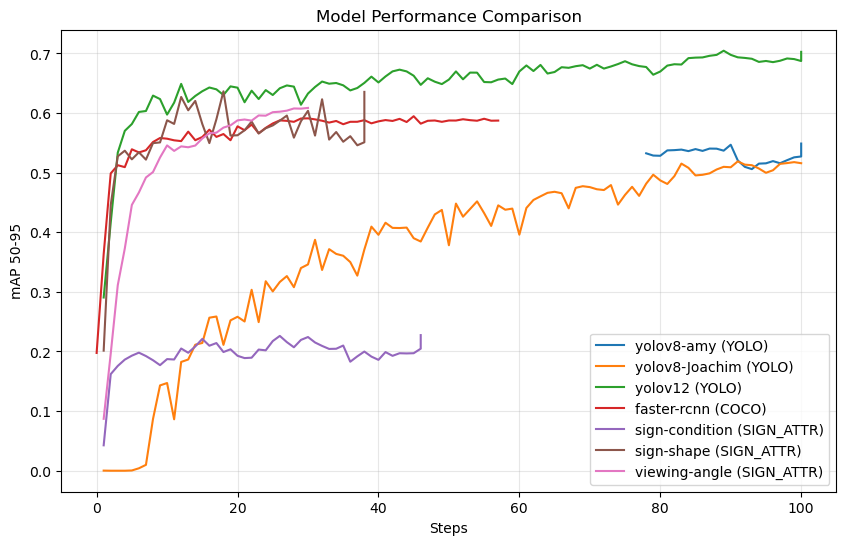

In [9]:
plt.figure(figsize=(10, 6))

for df in dataframes_list:
    if df.empty:
        continue
        
    # FIX: Use .unique() to get the list of tags only once
    headers = df['metric'].unique()
    
    for header in headers:
        # Check for your specific metric
        if 'mAP' in header and '50' in header and '95' in header:
            
            subset = df[df['metric'] == header]
            
            # Plot once per model/metric
            plt.plot(
                subset['step'], 
                subset['value'], 
                label=f"{df['model'].iloc[0]} ({df['category'].iloc[0]})" # Added category for clarity
            )

plt.xlabel('Steps')
plt.ylabel('mAP 50-95')
plt.title('Model Performance Comparison')
plt.legend() # <--- Essential to see which line is which!
plt.grid(True, alpha=0.3)
plt.show()